In [1]:
# import classy module
from classy import Class

In [2]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
import numpy as np
#from plotting_utils import plot_segments

fonsize = 14

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=True)
rc('font', family='serif', size=fonsize)

rcParams.update({
    'font.size': fonsize,
    'axes.titlesize': fonsize,
    'axes.labelsize': fonsize,
    'xtick.labelsize': fonsize,
    'ytick.labelsize': fonsize,
    'legend.fontsize': fonsize,
})

## Model parameter and argument definitions

In [3]:
#
# Louis old setup
#  # create instance of the class "Class"
# LambdaCDM = Class()
# # pass input parameters
# # LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
# LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
# LambdaCDM.set({'output':'tCl,pCl,lCl,mPknw','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0, 'nowiggle_pk_species':'total'})

# # run class
# LambdaCDM.compute()

# # get reduced Hubble for conversions to 1/Mpc
# h = LambdaCDM.h()

# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'tCl, pCl, lCl, mPknw','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0})



# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()

In [4]:
# Read data:
dir = '/Users/fynn/PhD/02-Research/01-Coding/class-bispectrum-png-fynn1410/notebooks/test_PNG_implementation/B_tree_without_AP.npz'

data = np.load(dir)

n_triag      = data["n_triag"]
k1_arr       = data["k1_arr"]
k2_arr       = data["k2_arr"]
k3_arr       = data["k3_arr"]
B0           = data["B0"]
B2           = data["B2"]
B4           = data["B4"]
b1           = np.array([ data["b1"] ])
b2           = np.array([ data["b2"] ])
bG2          = np.array([ data["bG2"] ])
s1           = 1 + 2 * np.array([ data["s1"] ])     # NOTE: conversion from 2(1+s1) to 1+s1
s2           = np.array([ data["s3"] ])             # NOTE: Louis switches s2 and s3
s3           = np.array([ data["s2"] ])             # NOTE: Louis switches s2 and s3
P_eps        = np.array([ data["P_eps"] ])
z            = np.array([ data["z"] ])
use_IR_resum = data["use_IR_resum"]


n_z = len(z)

# Additional parameters
q_orth = np.ones(n_z, dtype=np.float64)
q_parr = np.ones(n_z, dtype=np.float64)
AP     = 1/(q_parr * q_orth**2)

# set nonlinear scale for FoG damping
k_nonlinear = 1. # in 1/Mpc
c1_FoG = np.array([ 0. ])

# Set PNG parameters further down

print('b1 =', b1)
print('b2 =', b2)
print('bG2 =', bG2)
print('s1 =', s1)
print('s2 =', s2)
print('s3 =', s3)
print('P_eps =', P_eps)

print(f"n_triag = {n_triag}, z = {z}, use_IR_resum = {use_IR_resum}")
print(f"k1_arr shape: {k1_arr.shape}, B0 shape: {B0.shape}")


b1 = [1.5]
b2 = [-1.]
bG2 = [-0.35]
s1 = [0.]
s2 = [0.]
s3 = [0.]
P_eps = [4199.38827632]
n_triag = [   0    1    2 ... 4997 4998 4999], z = [0.95], use_IR_resum = 1
k1_arr shape: (5000,), B0 shape: (5000,)


In [5]:
# # Make the AP factors
# D_A_fid = 1663.9307801326001
# H_fid = 0.00037966933846752485

# h = LambdaCDM.h()
# H = np.zeros(n_z, 'float64')
# D_A = np.zeros(n_z, 'float64')
# for i in range(n_z):
#     D_A[i] = LambdaCDM.angular_distance(z[i]) # in Mpc
#     H[i]   = LambdaCDM.Hubble(z[i])           # in (Mpc)^(-1)

# #Alcock Pacinsky effect
# q_orth = D_A/D_A_fid  # 1/f_orth  # alpha_perp
# q_parr = H_fid/H                  # alpha_parallel

# print(q_orth, q_parr)

# q_orth = np.ones(n_z, dtype=np.float64)
# q_parr = np.ones(n_z, dtype=np.float64)


## Comparison between this code and Fynn's old code (no AP, no FoG, no fnl)

In [6]:
import time as t
t_start = t.perf_counter()


triangles = np.ascontiguousarray(np.column_stack([k1_arr, k2_arr, k3_arr]), dtype=np.float64)

# Set PNG parameter
bphi = np.array([1.])
bphidelta = np.array([1.])
fnl = 1.
fnl0 = 0. # as reference value
l_max = 4

B_l, derivs, alpha_k = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                          b1,
                                                                          b2,
                                                                          bG2,
                                                                          s1,
                                                                          s2,
                                                                          s3,
                                                                          P_eps,
                                                                          c1_FoG,
                                                                          k_nonlinear,
                                                                          bphi,
                                                                          bphidelta,
                                                                          fnl0,
                                                                          triangles,
                                                                          z,
                                                                          l_max,
                                                                          q_orth,
                                                                          q_parr,
                                                                          AP
)
t_end = t.perf_counter()
print(t_end-t_start)

0.09908724995329976


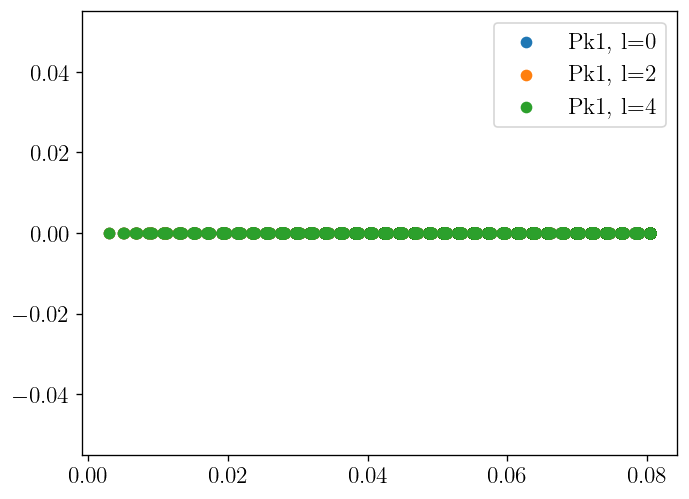

In [7]:


for i in range(3):
    plt.scatter(k1_arr, alpha_k[i,:], label='Pk1, l={}'.format(2*i))
plt.legend()


residual max deviation: 0.002%
residual max deviation: 0.009%
residual max deviation: 0.056%


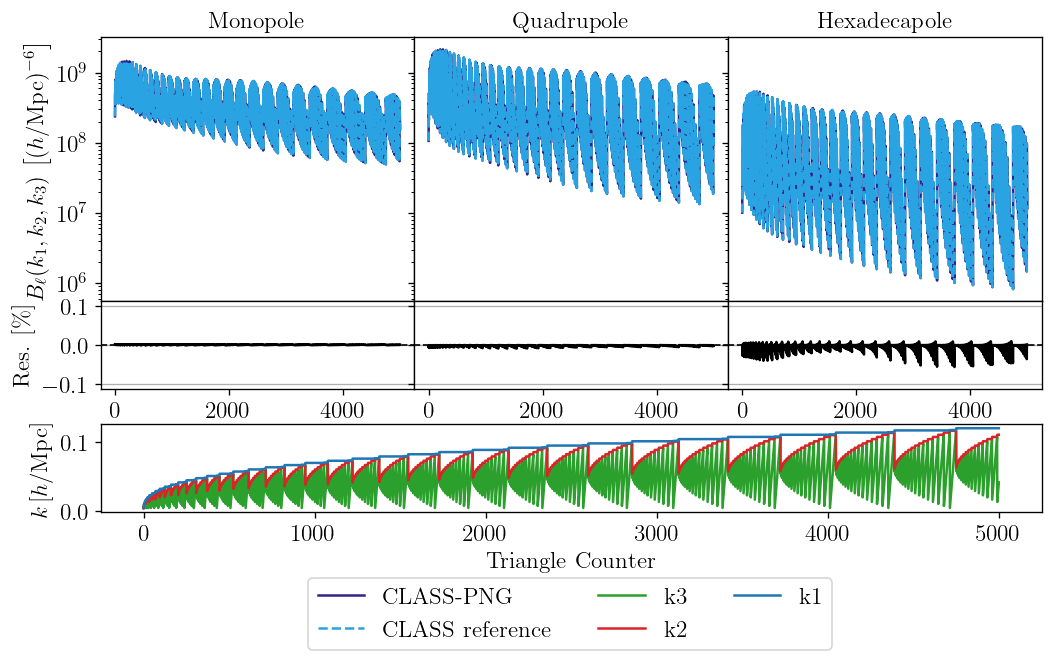

In [8]:
from test_PNG_implementation.python_tools.plotting import plot_comparison, plot_multipoles

model1_label = 'CLASS-PNG'
model2_label = 'CLASS reference'

iz = 0
l0, l2, l4 = 0, 1, 2
plot_comparison(n_triag,
                B_l[iz, l0, :], B0,
                B_l[iz, l2, :], B2,
                B_l[iz, l4, :], B4,
                k1_arr, k2_arr, k3_arr,
                h,
                model1_label,
                model2_label)

# Equilateral Configuration

In [9]:
# plot equilateral triangles
k1_eq = np.logspace(-3, -1, len(n_triag))
k2_eq = k1_eq
k3_eq = k1_eq
n_triag_eq = np.arange(len(k1_eq))

triangles = np.ascontiguousarray(np.column_stack([k1_eq, k2_eq, k3_eq]), dtype=np.float64)


B_l, derivs, alpha_k = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                    b1,
                                                                                    b2,
                                                                                    bG2,
                                                                                    s1,
                                                                                    s2,
                                                                                    s3,
                                                                                    P_eps,
                                                                                    c1_FoG,
                                                                                    k_nonlinear,
                                                                                    bphi,
                                                                                    bphidelta,
                                                                                    fnl,
                                                                                    triangles,
                                                                                    z,
                                                                                    l_max,
                                                                                    q_orth,
                                                                                    q_parr,
                                                                                    AP
)

B_l_fnl0, derivs_fnl0, alpha_k_fnl0 = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                                b1,
                                                                                                b2,
                                                                                                bG2,
                                                                                                s1,
                                                                                                s2,
                                                                                                s3,
                                                                                                P_eps,
                                                                                                c1_FoG,
                                                                                                k_nonlinear,
                                                                                                bphi,
                                                                                                bphidelta,
                                                                                                fnl0,
                                                                                                triangles,
                                                                                                z,
                                                                                                l_max,
                                                                                                q_orth,
                                                                                                q_parr,
                                                                                                AP
)
t_end = t.perf_counter()
print(t_end-t_start)


0.8295577918179333


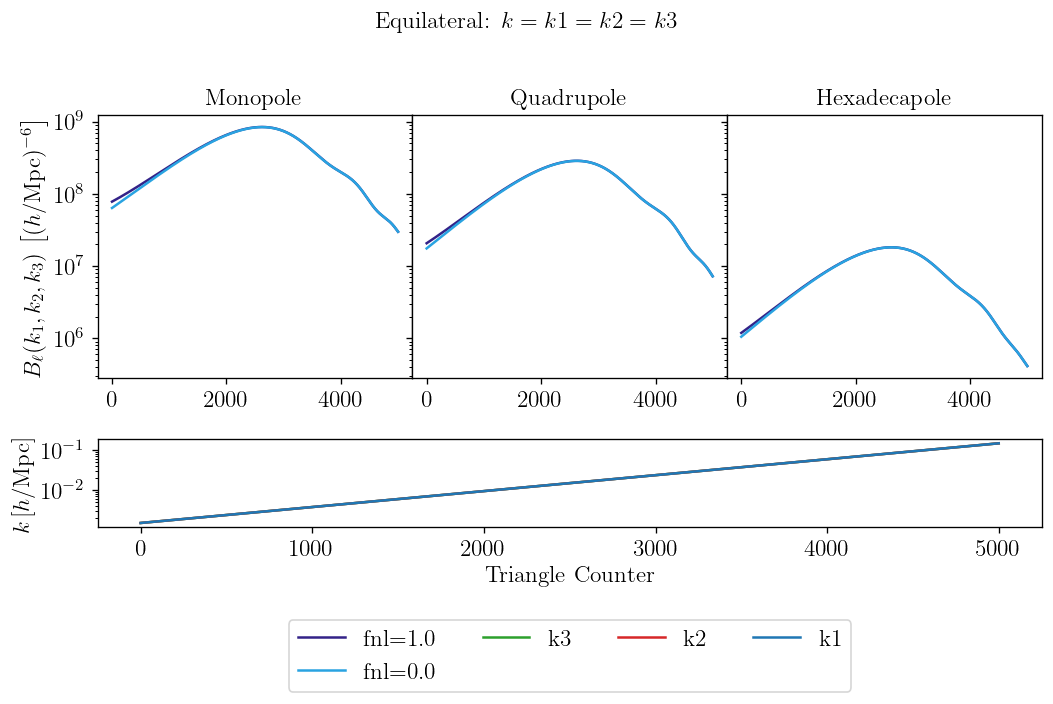

In [10]:
B0 = [ B_l[iz, l0, :], B_l_fnl0[iz, l0, :]]
B2 = [ B_l[iz, l2, :], B_l_fnl0[iz, l2, :]]
B4 = [ B_l[iz, l4, :], B_l_fnl0[iz, l4, :]]

labels = [f'fnl={fnl}', f'fnl={fnl0}']
global_title = 'Equilateral: $k=k1=k2=k3$'

plot_multipoles(n_triag_eq,
                B0, B2, B4,
                k1_eq, k2_eq, k3_eq,
                h,
                labels, 
                global_title)

# Squeezed Configuration

In [11]:
# plot equilateral triangles
k1_sq = np.logspace(-3, -1, len(n_triag))
k2_sq = k1_sq
k3_sq = 0.05 * k1_sq
n_triag_sq = np.arange(len(k1_sq))

triangles = np.ascontiguousarray(np.column_stack([k1_sq, k2_sq, k3_sq]), dtype=np.float64)

B_l, derivs, alpha_k = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                    b1,
                                                                                    b2,
                                                                                    bG2,
                                                                                    s1,
                                                                                    s2,
                                                                                    s3,
                                                                                    P_eps,
                                                                                    c1_FoG,
                                                                                    k_nonlinear,
                                                                                    bphi,
                                                                                    bphidelta,
                                                                                    fnl,
                                                                                    triangles,
                                                                                    z,
                                                                                    l_max,
                                                                                    q_orth,
                                                                                    q_parr,
                                                                                    AP
)

B_l_fnl0, derivs_fnl0, alpha_k_fnl0 = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                                b1,
                                                                                                b2,
                                                                                                bG2,
                                                                                                s1,
                                                                                                s2,
                                                                                                s3,
                                                                                                P_eps,
                                                                                                c1_FoG,
                                                                                                k_nonlinear,
                                                                                                bphi,
                                                                                                bphidelta,
                                                                                                fnl0,
                                                                                                triangles,
                                                                                                z,
                                                                                                l_max,
                                                                                                q_orth,
                                                                                                q_parr,
                                                                                                AP
)
t_end = t.perf_counter()
print(t_end-t_start)


1.7488443749025464


<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/var/folders/ff/6cytkh094g35kn8sx9zksh8h0000gn/T/ipykernel_85167/4290945323.py:6: SyntaxWarning: invalid escape sequence '\c'
  global_title = 'Squeezed: $k=k1=k2=20 \cdot k3$'


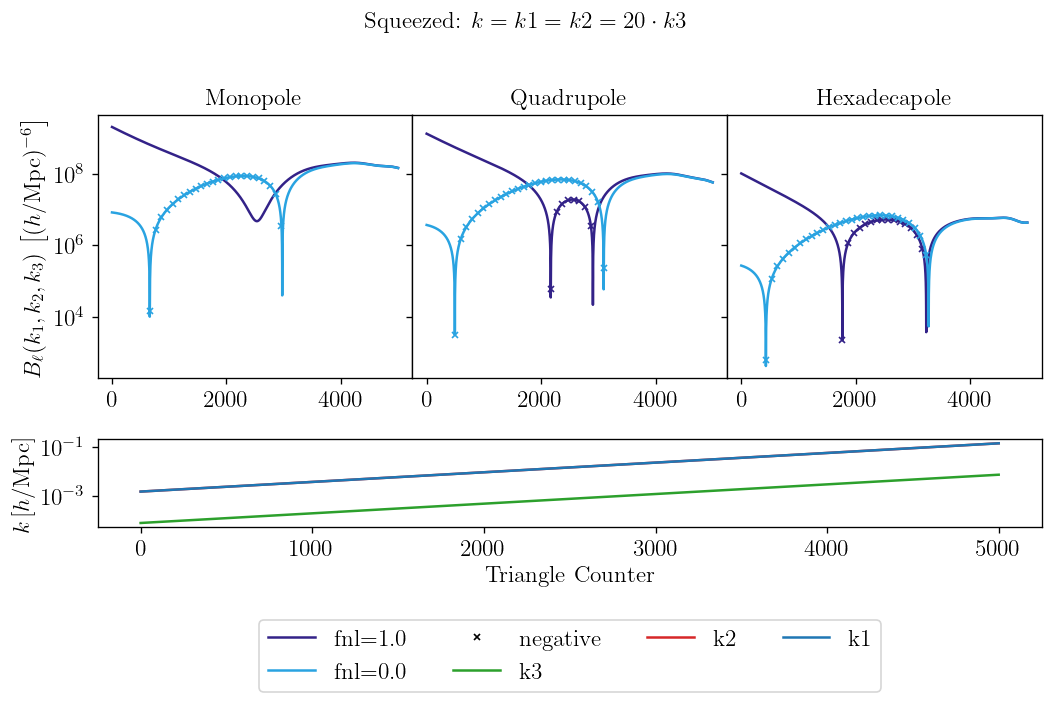

In [12]:
B0 = [ B_l[iz, l0, :], B_l_fnl0[iz, l0, :]]
B2 = [ B_l[iz, l2, :], B_l_fnl0[iz, l2, :]]
B4 = [ B_l[iz, l4, :], B_l_fnl0[iz, l4, :]]

labels = [f'fnl={fnl}', f'fnl={fnl0}']
global_title = 'Squeezed: $k=k1=k2=20 \cdot k3$'


plot_multipoles(n_triag_sq,
                B0, B2, B4,
                k1_sq, k2_sq, k3_sq,
                h,
                labels,
                global_title)

# Isoscelese

In [13]:
# plot equilateral triangles
k1_iso = np.logspace(-3, -1, len(n_triag))
k2_iso = k1_iso
k3_iso = 0.5 * k1_iso
n_triag_iso = np.arange(len(k1_iso))

triangles = np.ascontiguousarray(np.column_stack([k1_iso, k2_iso, k3_iso]), dtype=np.float64)


B_l, derivs, alpha_k = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                    b1,
                                                                                    b2,
                                                                                    bG2,
                                                                                    s1,
                                                                                    s2,
                                                                                    s3,
                                                                                    P_eps,
                                                                                    c1_FoG,
                                                                                    k_nonlinear,
                                                                                    bphi,
                                                                                    bphidelta,
                                                                                    fnl,
                                                                                    triangles,
                                                                                    z,
                                                                                    l_max,
                                                                                    q_orth,
                                                                                    q_parr,
                                                                                    AP
)

B_l_fnl0, derivs_fnl0, alpha_k_fnl0 = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                                b1,
                                                                                                b2,
                                                                                                bG2,
                                                                                                s1,
                                                                                                s2,
                                                                                                s3,
                                                                                                P_eps,
                                                                                                c1_FoG,
                                                                                                k_nonlinear,
                                                                                                bphi,
                                                                                                bphidelta,
                                                                                                fnl0,
                                                                                                triangles,
                                                                                                z,
                                                                                                l_max,
                                                                                                q_orth,
                                                                                                q_parr,
                                                                                                AP
)
t_end = t.perf_counter()
print(t_end-t_start)


2.3083122498355806


<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/var/folders/ff/6cytkh094g35kn8sx9zksh8h0000gn/T/ipykernel_85167/4213189879.py:6: SyntaxWarning: invalid escape sequence '\c'
  global_title = 'Isosceles: $k=k1=k2=2 \cdot k3$'


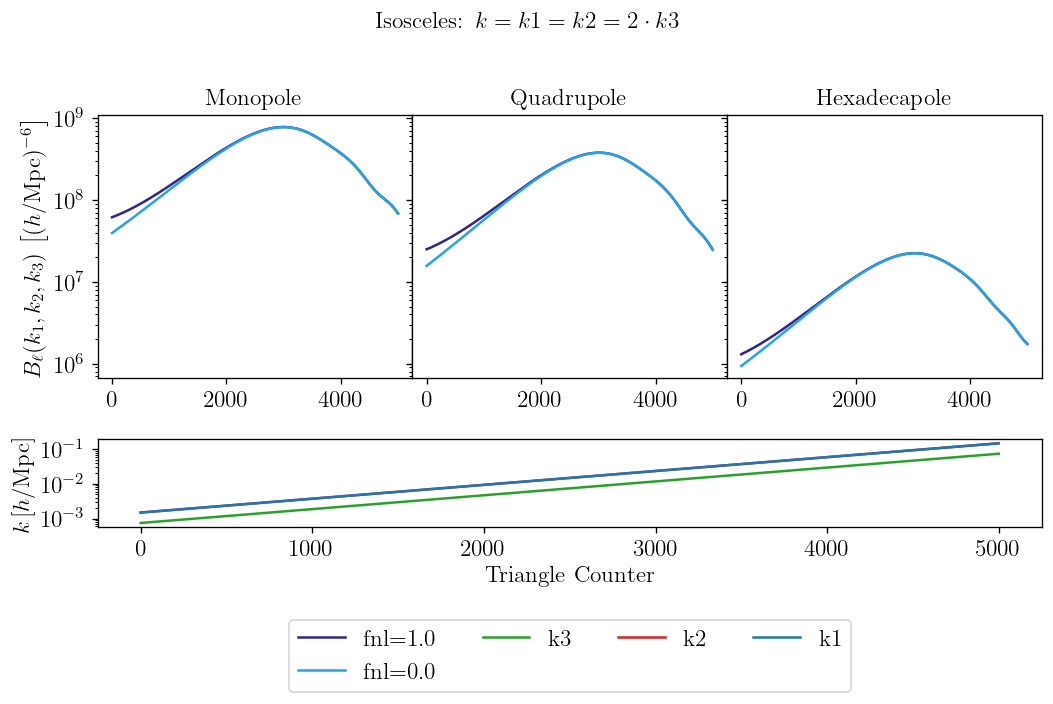

In [14]:
B0 = [ B_l[iz, l0, :], B_l_fnl0[iz, l0, :]]
B2 = [ B_l[iz, l2, :], B_l_fnl0[iz, l2, :]]
B4 = [ B_l[iz, l4, :], B_l_fnl0[iz, l4, :]]

labels = [f'fnl={fnl}', f'fnl={fnl0}']
global_title = 'Isosceles: $k=k1=k2=2 \cdot k3$'

plot_multipoles(n_triag_iso,
                B0, B2, B4,
                k1_iso, k2_iso, k3_iso,
                h,
                labels,
                global_title)